# Messy Mashup Genre Classification

## Milestone 1 — EDA


In [1]:
import os
import numpy as np
import pandas as pd

import librosa
import librosa.display

import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
BASE = "/kaggle/input/competitions/jan-2026-dl-gen-ai-project/messy_mashup"

GENRES_PATH = os.path.join(BASE, "genres_stems")
MASHUPS_PATH = os.path.join(BASE, "mashups")
TEST_CSV = os.path.join(BASE, "test.csv")

In [3]:
print(os.listdir(BASE))

['ESC-50-master', 'sample_submission.csv', 'genres_stems', 'mashups', 'test.csv']


In [4]:
genres = sorted(os.listdir(GENRES_PATH))

print("Genres:", genres)
print("Total genres:", len(genres))

Genres: ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']
Total genres: 10


In [5]:
sample_genre = genres[0]

genre_path = os.path.join(GENRES_PATH, sample_genre)

songs = os.listdir(genre_path)

print("Example songs:", songs[:5])

Example songs: ['blues.00095', 'blues.00006', 'blues.00056', 'blues.00097', 'blues.00065']


In [6]:
song_folder = os.path.join(genre_path, songs[0])

print(os.listdir(song_folder))

['drums.wav', 'vocals.wav', 'bass.wav', 'other.wav']


In [7]:
#Load one stem 

drums_path = os.path.join(song_folder, "drums.wav")

audio, sr = librosa.load(drums_path, sr=22050)

print("Sample rate:", sr)
print("Audio length:", len(audio))
print("Duration (seconds):", len(audio)/sr)

Sample rate: 22050
Audio length: 661794
Duration (seconds): 30.013333333333332


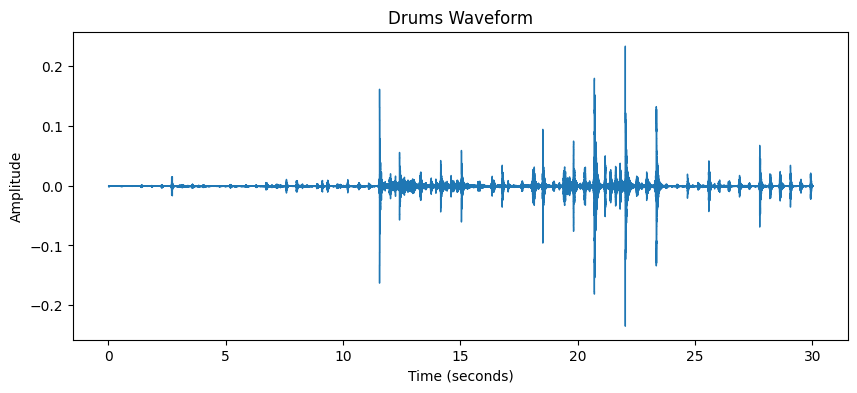

In [8]:
plt.figure(figsize=(10,4))

librosa.display.waveshow(audio, sr=sr)

plt.title("Drums Waveform")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

In [9]:
mel = librosa.feature.melspectrogram(
    y=audio,
    sr=sr,
    n_mels=128
)

mel_db = librosa.power_to_db(mel)

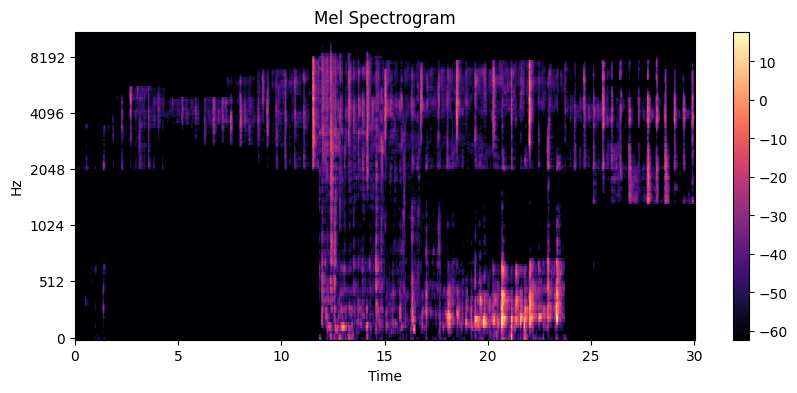

In [10]:
plt.figure(figsize=(10,4))

librosa.display.specshow(
    mel_db,
    sr=sr,
    x_axis="time",
    y_axis="mel"
)

plt.title("Mel Spectrogram")
plt.colorbar()

plt.show()

In [11]:
# Combine Stems to Simulate Full Song

stems = ["drums.wav","bass.wav","vocals.wav","other.wav"]

audio_sum = None
sr = 22050

for stem in stems:

    path = os.path.join(song_folder, stem)

    if not os.path.exists(path):
        continue

    try:
        y, sr = librosa.load(path, sr=sr)
    except:
        continue

    if audio_sum is None:
        audio_sum = y
    else:
        min_len = min(len(audio_sum), len(y))
        audio_sum = audio_sum[:min_len] + y[:min_len] * 0.25

if audio_sum is None:
    audio_sum = np.zeros(sr*5)

print("Combined audio samples:", len(audio_sum))
print("Duration (seconds):", len(audio_sum)/sr)


Combined audio samples: 661794
Duration (seconds): 30.013333333333332


In [12]:
test_df = pd.read_csv(TEST_CSV)

test_df.head()

,id,filename
0,1,mashups/song0001.wav
1,2,mashups/song0002.wav
2,3,mashups/song0003.wav
3,4,mashups/song0004.wav
4,5,mashups/song0005.wav


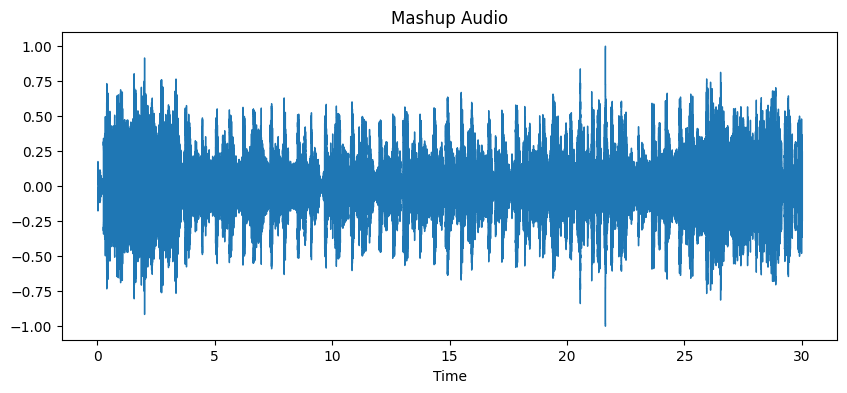

In [13]:
sample_mashup = os.path.join(MASHUPS_PATH, "song0001.wav")

audio, sr = librosa.load(sample_mashup, sr=22050)

plt.figure(figsize=(10,4))

librosa.display.waveshow(audio, sr=sr)

plt.title("Mashup Audio")
plt.show()

In [14]:
# Baseline submission... random prediction

import random

predictions = []

for _ in range(len(test_df)):
    predictions.append(random.choice(genres))

In [15]:
submission = pd.DataFrame({
    "id": test_df["id"],
    "genre": predictions
})

submission.to_csv("submission.csv", index=False)

submission.head()

,id,genre
0,1,blues
1,2,jazz
2,3,metal
3,4,jazz
4,5,disco
